# Q5 — Corrected classification pipeline
Adapted from `../q5_starter_classifier.py`. Run all cells in order. Dependencies: Python and NumPy (plus Jupyter to run this notebook). Paths support launching from this folder, the course root, or the supplied-data folder.

The comments identify repairs by original starter line numbers. This notebook contains implementation and diagnostic evidence, **not the required student-written reflection**. AI assistance and checks are recorded in `q5_ai_conversation_log.md`; the student must independently validate the claims and results.

Execution note: all code cells were successfully executed in order with a Python 3 Jupyter kernel through nbclient.

In [1]:
from pathlib import Path
import numpy as np

# NOTEBOOK CONVERSION ONLY (not a starter-code error or pipeline repair):
# The original .py file correctly used __file__ to locate its data.
# Notebooks do not define __file__, so use relative paths here instead.
candidates = [Path('..'), Path('Homework/Homework1'), Path('.')]
DATA_DIR = next((p for p in candidates if (p / 'Q1_train.csv').is_file()
                 and (p / 'Q1_test.csv').is_file()), None)
if DATA_DIR is None:
    raise FileNotFoundError('Keep the supplied Q1 CSVs in Homework1, the parent of Homework1-Solutions.')


def load_data(path):
    # REPAIR (starter line 27): CSVs have a header; parsing F1 as float fails.
    data = np.loadtxt(path, delimiter=',', skiprows=1)
    if data.ndim != 2 or data.shape[1] != 5 or not np.isfinite(data).all():
        raise ValueError('Expected five finite numeric columns.')
    if not np.isin(data[:, -1], [0, 1]).all():
        raise ValueError('Expected binary labels 0 and 1.')
    return data


train = load_data(DATA_DIR / 'Q1_train.csv')
test = load_data(DATA_DIR / 'Q1_test.csv')
# REPAIR (lines 50–54): remove Class BEFORE any feature processing.
# Extracting y alone did not remove the labels from the starter distance inputs.
X_train, y_train = train[:, :-1], train[:, -1].astype(int)
X_test, y_test = test[:, :-1], test[:, -1].astype(int)
print('Training features:', X_train.shape, 'Test features:', X_test.shape)
print('Classes:', np.unique(y_train))

Training features: (910, 4) Test features: (462, 4)
Classes: [0 1]


In [2]:
class StandardScaler:
    def fit(self, x):
        self.mean_ = np.mean(x, axis=0)
        self.scale_ = np.std(x, axis=0)
        # Retain the starter's valid zero-variance protection.
        self.scale_[self.scale_ == 0] = 1
        return self

    def transform(self, x):
        return (x - self.mean_) / self.scale_


def euclidean_distance(a, b):
    # REPAIR (line 31): signed differences can cancel or become negative.
    return np.sqrt(np.sum((a - b) ** 2))


def predict_knn(train_x, train_y, query, k):
    if not 1 <= k <= len(train_x):
        raise ValueError('k must be between 1 and the number of training rows.')
    distances = np.array([euclidean_distance(query, row) for row in train_x])
    # Stable sorting makes equal-distance selection reproducible by row order.
    nearest = np.argsort(distances, kind='stable')[:k]
    votes = train_y[nearest]
    classes, counts = np.unique(votes, return_counts=True)
    tied = classes[counts == counts.max()]
    # REPAIR (line 38): bincount(...).argmax() silently favors class 0 in a tie.
    # Follow Q1: among classes tied for most votes, use the nearest neighbor.
    return next(label for label in votes if label in tied)


def predict_many(train_x, train_y, queries, k):
    return np.array([predict_knn(train_x, train_y, q, k) for q in queries])


def evaluate(y_true, y_pred):
    # Explicit row/column labels: rows=true, columns=predicted, order [0, 1].
    cm = np.zeros((2, 2), dtype=int)
    np.add.at(cm, (y_true, y_pred), 1)
    tp = np.diag(cm)
    denom = cm.sum(axis=0) + cm.sum(axis=1)
    f1 = np.divide(2 * tp, denom, out=np.zeros(2, dtype=float), where=denom != 0)
    return np.mean(y_true == y_pred), f1.mean(), cm


def report(name, truth, predictions):
    accuracy, macro_f1, cm = evaluate(truth, predictions)
    print(f'{name}: accuracy={accuracy:.3f}, macro-F1={macro_f1:.3f}')
    print('                 predicted 0  predicted 1')
    for label, row in enumerate(cm):
        print(f'true {label}           {row[0]:10d}   {row[1]:10d}')

## Select K using training data only
A fixed K of 4 is not inherently wrong. Here its unexplained choice is replaced with a reproducible, stratified 80/20 split of the training set and a search over K=1,…,9. Select by validation macro-F1; an exact tie favors smaller K. Fit the validation scaler on the fitting subset only. This single split is a limited estimate of stability, not cross-validation. Test labels and test statistics do not enter model selection.

In [3]:
rng = np.random.default_rng(883)
fit_idx, val_idx = [], []
for label in np.unique(y_train):
    indices = rng.permutation(np.flatnonzero(y_train == label))
    n_val = max(1, int(round(0.2 * len(indices))))
    val_idx.extend(indices[:n_val])
    fit_idx.extend(indices[n_val:])
fit_idx, val_idx = np.array(fit_idx), np.array(val_idx)

# REPAIR (line 50): fit preprocessing only on data used to fit the model.
val_scaler = StandardScaler().fit(X_train[fit_idx])
X_fit_scaled = val_scaler.transform(X_train[fit_idx])
X_val_scaled = val_scaler.transform(X_train[val_idx])
validation_scores = {}
print('K  validation accuracy  validation macro-F1')
for k in range(1, 10):
    predictions = predict_many(X_fit_scaled, y_train[fit_idx], X_val_scaled, k)
    accuracy, macro_f1, _ = evaluate(y_train[val_idx], predictions)
    validation_scores[k] = macro_f1
    print(f'{k}       {accuracy:.3f}               {macro_f1:.3f}')
best_k = max(validation_scores, key=lambda k: (validation_scores[k], -k))
print('Selected K:', best_k)

# Refit on all training features after selection, then transform test features.
scaler = StandardScaler().fit(X_train)
train_scaled = scaler.transform(X_train)
test_scaled = scaler.transform(X_test)

K  validation accuracy  validation macro-F1


1       1.000               1.000


2       1.000               1.000


3       1.000               1.000


4       1.000               1.000


5       1.000               1.000


6       1.000               1.000


7       1.000               1.000


8       1.000               1.000


9       1.000               1.000
Selected K: 1


## Gaussian Naive Bayes comparison
Q1 has four numeric features. Gaussian Naive Bayes provides a continuous-feature baseline by estimating a mean and variance for each feature within each class. Conditional Gaussian distributions and conditional independence are approximations, not established facts about these data. Correlation or non-Gaussian class distributions could limit performance. The implementation below uses empirical training class priors, log probabilities to avoid multiplying tiny densities, and a small variance floor for numerical stability. No test-based tuning is used.

In [4]:
class GaussianNaiveBayes:
    def fit(self, x, y):
        self.classes_, counts = np.unique(y, return_counts=True)
        self.log_priors_ = np.log(counts / len(y))
        self.means_ = np.array([x[y == c].mean(axis=0) for c in self.classes_])
        variances = np.array([x[y == c].var(axis=0) for c in self.classes_])
        self.variances_ = np.maximum(variances, 1e-9)
        return self

    def predict(self, x):
        differences = x[:, None, :] - self.means_[None, :, :]
        log_likelihood = -0.5 * np.sum(
            np.log(2 * np.pi * self.variances_)[None, :, :]
            + differences ** 2 / self.variances_[None, :, :], axis=2)
        return self.classes_[np.argmax(log_likelihood + self.log_priors_, axis=1)]


knn_predictions = predict_many(train_scaled, y_train, test_scaled, best_k)
nb_model = GaussianNaiveBayes().fit(train_scaled, y_train)
nb_predictions = nb_model.predict(test_scaled)
report(f'Corrected KNN (K={best_k})', y_test, knn_predictions)
report('Gaussian Naive Bayes', y_test, nb_predictions)

Corrected KNN (K=1): accuracy=0.998, macro-F1=0.998
                 predicted 0  predicted 1
true 0                  261            1
true 1                    0          200
Gaussian Naive Bayes: accuracy=0.874, macro-F1=0.871
                 predicted 0  predicted 1
true 0                  238           24
true 1                   34          166


## Diagnostic evidence
These checks are AI-run implementation checks. Reproduce and reason through them independently before using their conclusions in your report. The starter comparison below skips the CSV header so that its remaining defects can be observed. It is not a successful run of the unmodified starter, and the comparison changes several things at once; it does not isolate each repair's effect on accuracy.

In [5]:
# Distance: a 3–4–5 triangle and cancellation between unequal points.
assert euclidean_distance(np.array([0., 0.]), np.array([3., 4.])) == 5
assert np.isclose(euclidean_distance(np.array([0., 0.]), np.array([3., -3.])), np.sqrt(18))
print('Signed-sum cancellation:', np.sum(np.array([0., 0.]) - np.array([3., -3.])))
print('Correct distance:', euclidean_distance(np.array([0., 0.]), np.array([3., -3.])))
# Vote tie: nearest point has class 1; smallest-class tie breaking returns 0.
assert predict_knn(np.array([[0.], [1.], [2.], [3.]]),
                   np.array([0, 0, 1, 1]), np.array([4.]), 4) == 1
# Feature separation and training-only scaling, including zero variance.
assert train_scaled.shape[1] == test_scaled.shape[1] == 4
assert np.allclose(scaler.mean_, X_train.mean(axis=0))
constant = np.array([[2., 1.], [2., 3.]])
assert np.isfinite(StandardScaler().fit(constant).transform(constant)).all()
print('Training-only feature means:', scaler.mean_)
print('Pooled feature means:', np.vstack([X_train, X_test]).mean(axis=0))
# Hand-checkable metrics: confusion [[1,1],[0,2]], accuracy .75, macro-F1 11/15.
a, f, cm = evaluate(np.array([0, 0, 1, 1]), np.array([0, 1, 1, 1]))
assert a == 0.75 and np.isclose(f, 11 / 15)
assert np.array_equal(cm, [[1, 1], [0, 2]])
# NB symmetry: equal priors/variances, means -2 and 2; classify by nearer mean.
toy_nb = GaussianNaiveBayes().fit(np.array([[-3.], [-1.], [1.], [3.]]), np.array([0, 0, 1, 1]))
assert np.array_equal(toy_nb.predict(np.array([[-2.], [2.]])), [0, 1])
print('Focused checks passed.')

# Reproduce original logic AFTER bypassing only its header-loading failure.
pooled_scaler = StandardScaler().fit(np.vstack([train, test]))
original_train = pooled_scaler.transform(train)
original_test = pooled_scaler.transform(test)
original_predictions, neighbor_sets = [], set()
for query in original_test:
    distances = np.array([np.sum(query - row) for row in original_train])
    nearest = np.argsort(distances)[:4]
    neighbor_sets.add(tuple(sorted(nearest)))
    original_predictions.append(np.bincount(y_train[nearest]).argmax())
print('Starter distinct neighbor sets:', len(neighbor_sets))
report('Starter logic (header bypass only)', y_test, np.array(original_predictions))

Signed-sum cancellation: 0.0
Correct distance: 4.242640687119285
Training-only feature means: [ 0.43836132  2.009717    1.33862628 -1.2055323 ]
Pooled feature means: [ 0.43373526  1.92235312  1.39762712 -1.19165652]
Focused checks passed.


Starter distinct neighbor sets: 1
Starter logic (header bypass only): accuracy=0.567, macro-F1=0.362
                 predicted 0  predicted 1
true 0                  262            0
true 1                  200            0


## Exploratory investigation: feature dependence and distributions
Appended investigation; the original model code and results above are preserved.

Naive Bayes assumes **conditional independence given the class**, not independence in the combined dataset. We inspect only the fitting subset of the existing training split, leaving its validation subset for comparison. These diagnostics use matplotlib in addition to NumPy. Nonzero within-class correlations suggest dependence; zero correlation does not establish independence. Histogram shape alone does not establish Gaussianity.

Because the test results have already been seen and prompted this exploration, these are exploratory model-development results. We do not use test data here or replace the earlier test comparison. Reusing one validation split also limits the strength of conclusions.

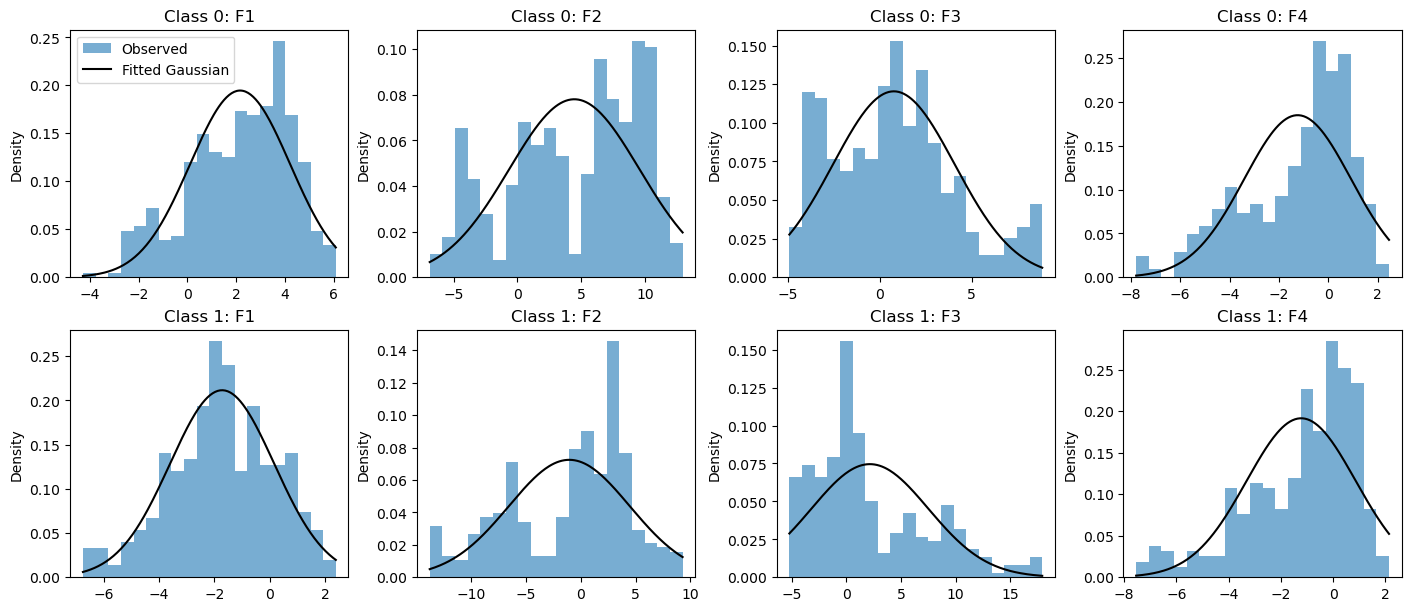

Class 0 correlations (F1-F4):
[[ 1.    -0.212 -0.347  0.412]
 [-0.212  1.    -0.741 -0.672]
 [-0.347 -0.741  1.     0.414]
 [ 0.412 -0.672  0.414  1.   ]]
Class 1 correlations (F1-F4):
[[ 1.     0.091 -0.478  0.292]
 [ 0.091  1.    -0.896 -0.524]
 [-0.478 -0.896  1.     0.308]
 [ 0.292 -0.524  0.308  1.   ]]


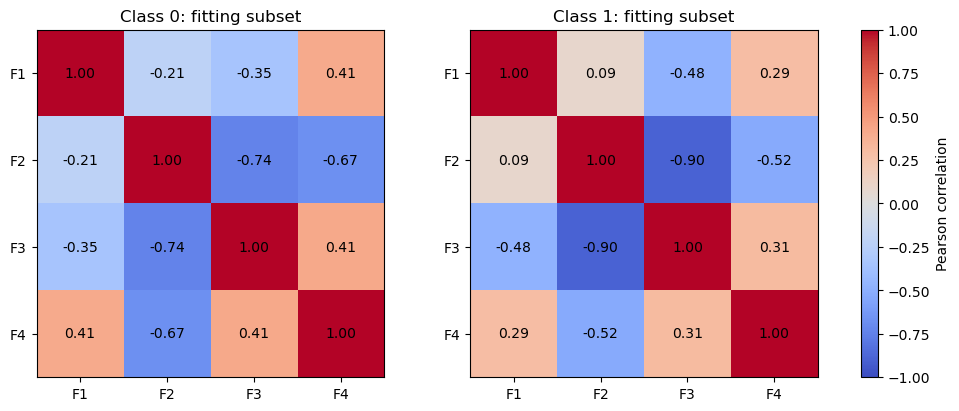

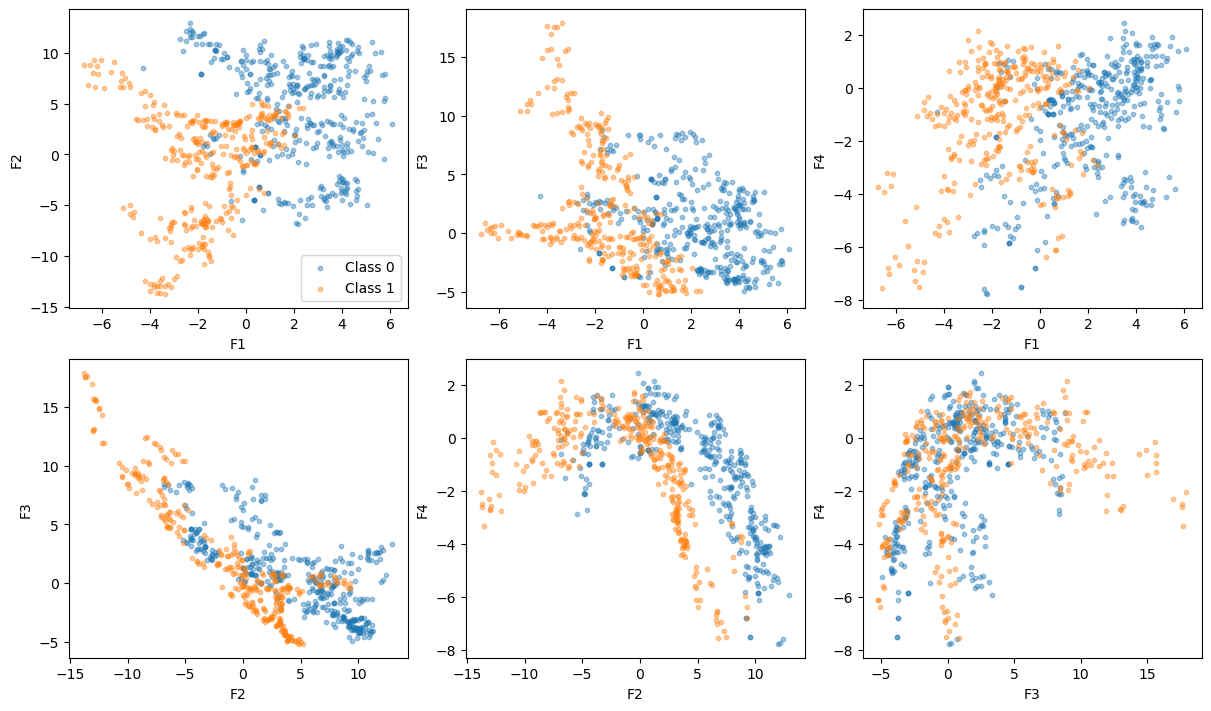

In [6]:
import matplotlib.pyplot as plt
from itertools import combinations

explore_x = X_train[fit_idx]  # Original units; fitting subset only.
explore_y = y_train[fit_idx]
feature_names = ['F1', 'F2', 'F3', 'F4']
figure_dir = Path('figures') if Path('q5_corrected.ipynb').is_file() else DATA_DIR / 'Homework1-Solutions' / 'figures'
figure_dir.mkdir(parents=True, exist_ok=True)

# Each histogram is compared with a Gaussian fitted to that same class/feature.
fig, axes = plt.subplots(2, 4, figsize=(14, 6), constrained_layout=True)
for row, label in enumerate([0, 1]):
    group = explore_x[explore_y == label]
    for j, name in enumerate(feature_names):
        ax = axes[row, j]
        values = group[:, j]
        ax.hist(values, bins=20, density=True, alpha=0.6, label='Observed')
        mean, std = values.mean(), values.std()
        if std > 0:
            grid = np.linspace(values.min(), values.max(), 200)
            density = np.exp(-0.5 * ((grid - mean) / std) ** 2) / (std * np.sqrt(2*np.pi))
            ax.plot(grid, density, color='black', label='Fitted Gaussian')
        ax.set_title(f'Class {label}: {name}')
        ax.set_ylabel('Density')
axes[0, 0].legend()
fig.savefig(figure_dir / 'q5-feature-distributions.png', dpi=160)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
for ax, label in zip(axes, [0, 1]):
    group = explore_x[explore_y == label]
    # Handle a constant feature without dividing by zero.
    centered = group - group.mean(axis=0)
    cov = centered.T @ centered / len(group)
    std = np.sqrt(np.diag(cov))
    denominator = np.outer(std, std)
    corr = np.divide(cov, denominator, out=np.full_like(cov, np.nan), where=denominator > 0)
    print(f'Class {label} correlations (F1-F4):')
    print(np.array2string(corr, precision=3, suppress_small=True))
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap='coolwarm')
    ax.set_xticks(range(4), feature_names)
    ax.set_yticks(range(4), feature_names)
    ax.set_title(f'Class {label}: fitting subset')
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f'{corr[i,j]:.2f}', ha='center', va='center')
fig.colorbar(im, ax=axes, label='Pearson correlation')
fig.savefig(figure_dir / 'q5-class-correlations.png', dpi=160)
plt.show()

# Pair plots help reveal relationships that marginal histograms can hide.
fig, axes = plt.subplots(2, 3, figsize=(12, 7), constrained_layout=True)
for ax, (i, j) in zip(axes.flat, combinations(range(4), 2)):
    for label in [0, 1]:
        group = explore_x[explore_y == label]
        ax.scatter(group[:, i], group[:, j], s=10, alpha=0.4, label=f'Class {label}')
    ax.set_xlabel(feature_names[i])
    ax.set_ylabel(feature_names[j])
axes[0, 0].legend()
fig.savefig(figure_dir / 'q5-feature-pairs.png', dpi=160)
plt.show()

### Does allowing feature dependence help?
A multivariate Gaussian classifier with a separate covariance matrix per class (a regularized QDA model) allows within-class linear feature relationships. It is **not Naive Bayes**, because it uses a joint density rather than multiplying independent feature densities. It still assumes one multivariate Gaussian per class.

We compare the original Gaussian NB with a diagonal-covariance control and a full-covariance model. Both covariance variants use the same fixed variance floor of 1e-9; no hyperparameter search is performed. For these nonsingular data, their difference is primarily whether off-diagonal covariances are retained. An improvement on validation would support modeling dependence as useful, not prove that dependence explains the entire original test gap. Failure to improve would not establish independence.

In [7]:
class JointGaussianClassifier:
    def __init__(self, diagonal=False):
        self.diagonal = diagonal

    def fit(self, x, y):
        self.classes_, counts = np.unique(y, return_counts=True)
        self.log_priors_ = np.log(counts / len(y))
        self.means_ = []
        self.covariances_ = []
        self.log_determinants_ = []
        for label in self.classes_:
            group = x[y == label]
            mean = group.mean(axis=0)
            centered = group - mean
            covariance = centered.T @ centered / len(group)
            if self.diagonal:
                covariance = np.diag(np.diag(covariance))
            # Floor eigenvalues for a positive definite covariance.
            values, vectors = np.linalg.eigh(covariance)
            covariance = (vectors * np.maximum(values, 1e-9)) @ vectors.T
            sign, logdet = np.linalg.slogdet(covariance)
            if sign <= 0:
                raise ValueError('Covariance must be positive definite.')
            self.means_.append(mean)
            self.covariances_.append(covariance)
            self.log_determinants_.append(logdet)
        return self

    def predict(self, x):
        scores = []
        for index, label in enumerate(self.classes_):
            difference = x - self.means_[index]
            # Joint Gaussian quadratic term; solve instead of explicitly inverting.
            solved = np.linalg.solve(self.covariances_[index], difference.T).T
            quadratic = np.sum(difference * solved, axis=1)
            score = self.log_priors_[index] - 0.5 * (
                x.shape[1] * np.log(2*np.pi) + self.log_determinants_[index] + quadratic)
            scores.append(score)
        return self.classes_[np.argmax(np.array(scores).T, axis=1)]

explore_nb = GaussianNaiveBayes().fit(X_fit_scaled, y_train[fit_idx])
explore_diag = JointGaussianClassifier(diagonal=True).fit(X_fit_scaled, y_train[fit_idx])
explore_full = JointGaussianClassifier().fit(X_fit_scaled, y_train[fit_idx])
nb_val = explore_nb.predict(X_val_scaled)
diag_val = explore_diag.predict(X_val_scaled)
full_val = explore_full.predict(X_val_scaled)
# Diagonal joint Gaussian should reproduce the independent Gaussian model.
assert np.array_equal(nb_val, diag_val)
for name, predictions in [('Gaussian NB', nb_val), ('Diagonal Gaussian control', diag_val),
                          ('Full-covariance Gaussian', full_val)]:
    report(name + ' — VALIDATION ONLY', y_train[val_idx], predictions)
base_acc, base_f1, _ = evaluate(y_train[val_idx], nb_val)
full_acc, full_f1, _ = evaluate(y_train[val_idx], full_val)
print(f'Full covariance minus NB: accuracy={full_acc-base_acc:+.3f}, macro-F1={full_f1-base_f1:+.3f}')
print('No additional test evaluation performed. This comparison is exploratory.')

Gaussian NB — VALIDATION ONLY: accuracy=0.879, macro-F1=0.877
                 predicted 0  predicted 1
true 0                   93            7
true 1                   15           67
Diagonal Gaussian control — VALIDATION ONLY: accuracy=0.879, macro-F1=0.877
                 predicted 0  predicted 1
true 0                   93            7
true 1                   15           67
Full-covariance Gaussian — VALIDATION ONLY: accuracy=0.995, macro-F1=0.994
                 predicted 0  predicted 1
true 0                   99            1
true 1                    0           82
Full covariance minus NB: accuracy=+0.115, macro-F1=+0.118
No additional test evaluation performed. This comparison is exploratory.
